### 3 – Feature Engineering

#### Theory & Industrial Relevance
Hand‑crafted features from ultrasonic signals are still widely used in industrial NDT because they are interpretable and can be fed into explainable classifiers. Time‑domain statistics (RMS, kurtosis, crest factor) correlate with defect severity; frequency‑domain features reveal resonance shifts; time‑frequency representations (spectrograms, wavelets) capture transient behaviour.
A robust feature extraction pipeline is a core skill for signal processing engineers.

Feature extraction:   0%|          | 0/5000 [00:00<?, ?it/s]

Feature matrix shape: (5000, 23)


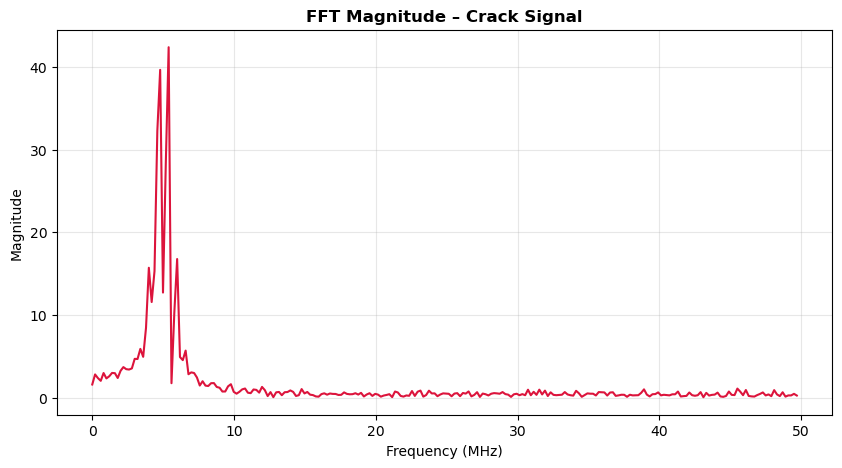

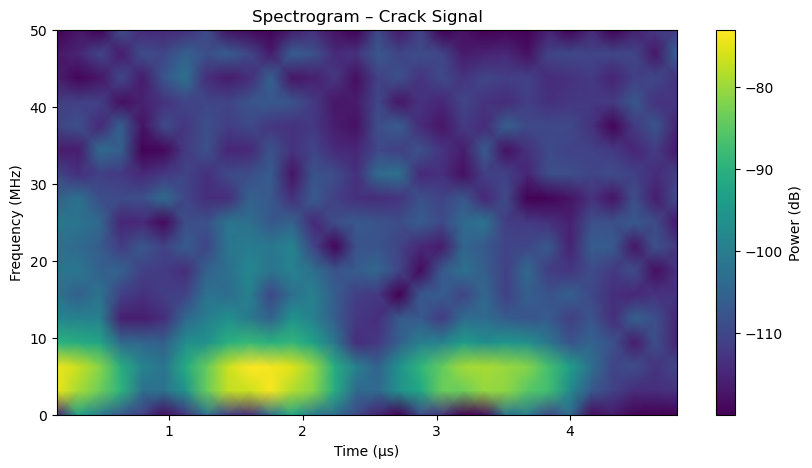

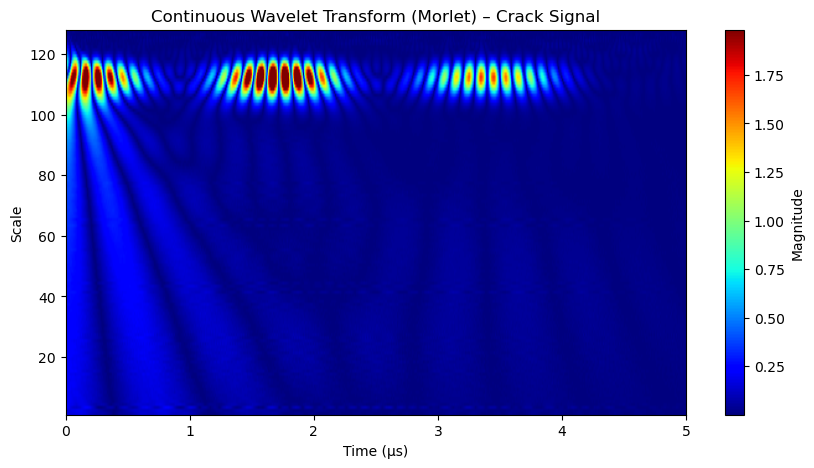

In [1]:
# ====================================================
# Notebook 03: Feature Engineering
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis
from scipy.signal import spectrogram, stft
import pywt
import pickle
from pathlib import Path
from tqdm.notebook import tqdm

# Load raw data
with open("../data/raw/signals.pkl", "rb") as f:
    signals_list, labels_list, TIME = pickle.load(f)

FS = 1 / (TIME[1] - TIME[0])
N = len(TIME)

def compute_time_features(signal: np.ndarray) -> dict:
    """Extract time‑domain features from an A‑scan."""
    features = {}
    features['mean'] = np.mean(signal)
    features['rms'] = np.sqrt(np.mean(signal**2))
    features['var'] = np.var(signal)
    features['std'] = np.std(signal)
    features['max'] = np.max(signal)
    features['min'] = np.min(signal)
    features['peak_to_peak'] = features['max'] - features['min']
    features['energy'] = np.sum(signal**2)
    # Entropy (using histogram)
    hist, _ = np.histogram(signal, bins=50, density=True)
    hist = hist[hist > 0]
    features['entropy'] = -np.sum(hist * np.log2(hist))
    features['skewness'] = skew(signal)
    features['kurtosis'] = kurtosis(signal)
    features['crest_factor'] = features['max'] / features['rms'] if features['rms'] != 0 else 0
    return features

def compute_freq_features(signal: np.ndarray, fs: float) -> dict:
    """Extract frequency‑domain features using FFT."""
    freq_signal = np.abs(fft(signal))[:N//2]
    freq_axis = fftfreq(N, 1/fs)[:N//2]
    psd = freq_signal ** 2
    features = {}
    features['dominant_freq'] = freq_axis[np.argmax(freq_signal)]
    # Spectral centroid
    if np.sum(psd) > 0:
        features['spectral_centroid'] = np.sum(freq_axis * psd) / np.sum(psd)
    else:
        features['spectral_centroid'] = 0
    # Spectral entropy
    psd_norm = psd / np.sum(psd) if np.sum(psd) > 0 else psd
    psd_norm = psd_norm[psd_norm > 0]
    features['spectral_entropy'] = -np.sum(psd_norm * np.log2(psd_norm))
    # Spectral bandwidth (weighted standard deviation)
    if np.sum(psd) > 0:
        centroid = features['spectral_centroid']
        features['spectral_bandwidth'] = np.sqrt(np.sum(psd * (freq_axis - centroid)**2) / np.sum(psd))
    else:
        features['spectral_bandwidth'] = 0
    features['peak_frequency'] = freq_axis[np.argmax(freq_signal)]
    return features

def compute_wavelet_energy(signal: np.ndarray, wavelet: str = 'db4', level: int = 4) -> dict:
    """Wavelet decomposition and relative energy per band."""
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = []
    for c in coeffs:
        energies.append(np.sum(np.square(c)))
    total = np.sum(energies)
    feat = {}
    for i, e in enumerate(energies):
        feat[f'wavelet_energy_{i}'] = e / total if total != 0 else 0
    return feat

# Extract features for all signals
feature_list = []
for sig in tqdm(signals_list, desc="Feature extraction"):
    t_feat = compute_time_features(sig)
    f_feat = compute_freq_features(sig, FS)
    w_feat = compute_wavelet_energy(sig, level=4)
    combined = {**t_feat, **f_feat, **w_feat}
    feature_list.append(combined)

df_features = pd.DataFrame(feature_list)
df_features['label'] = labels_list
df_features.to_csv("../data/processed/features.csv", index=False)

print(f"Feature matrix shape: {df_features.shape}")
df_features.head()

# ====================================================
# Visualisations
# ====================================================
# 1. FFT of a sample (Crack)
crack_idx = np.where(np.array(labels_list) == 1)[0][0]
crack_sig = signals_list[crack_idx]
fft_vals = np.abs(fft(crack_sig))[:N//2]
freqs = fftfreq(N, 1/FS)[:N//2]

plt.figure(figsize=(10, 5))
plt.plot(freqs/1e6, fft_vals, color='crimson')
plt.title("FFT Magnitude – Crack Signal", fontweight='bold')
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.3)
plt.savefig("../images/fft_crack.png", dpi=300)
plt.show()

# 2. Spectrogram
f, t_spec, Sxx = spectrogram(crack_sig, fs=FS, nperseg=32, noverlap=16)
plt.figure(figsize=(10, 5))
plt.pcolormesh(t_spec*1e6, f/1e6, 10*np.log10(Sxx + 1e-12), shading='gouraud')
plt.title("Spectrogram – Crack Signal")
plt.xlabel("Time (µs)")
plt.ylabel("Frequency (MHz)")
plt.colorbar(label="Power (dB)")
plt.savefig("../images/spectrogram_crack.png", dpi=300)
plt.show()

# 3. Continuous Wavelet Transform (CWT) scalogram
scales = np.arange(1, 128)
cwtmatr, freqs_cwt = pywt.cwt(crack_sig, scales, 'morl', sampling_period=1/FS)
plt.figure(figsize=(10, 5))
plt.imshow(np.abs(cwtmatr), extent=[TIME[0]*1e6, TIME[-1]*1e6, 1, 128],
           aspect='auto', cmap='jet', vmax=np.abs(cwtmatr).max()*0.6)
plt.title("Continuous Wavelet Transform (Morlet) – Crack Signal")
plt.xlabel("Time (µs)")
plt.ylabel("Scale")
plt.colorbar(label="Magnitude")
plt.savefig("../images/cwt_crack.png", dpi=300)
plt.show()

#### Interpretation of Result
The FFT of a crack shows a dominant peak at the transducer centre frequency (5 MHz) but with some broadening due to damping. The spectrogram reveals the time‑localisation of the crack echo. The wavelet scalogram clearly separates the front‑wall, defect, and back‑wall echoes across scales.
The feature table now quantifies each signal with 20+ engineering features ready for modelling.